In [1]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

Most of this follows 

Maximum entropy in the problem of moments

Mean and Papanicolaou

http://link.aip.org/link/doi/10.1063/1.526446?ver=pdfcov

In [ ]:
def getGamma(lam,un,x):
    N = len(lam)
    M = len(x)
    # assume uniform spacing
    dx = x[1]-x[0] 
    
    # make a power matrix 
    XN = np.zeros([N,M])
    for n in range(1,N+1):
        XN[n-1]=np.power(x,n)

    # MP 2.4
    # evaluate z by using the dot product to take the sum inside the exponential 
    # the second sum is the integral
    Z = dx * np.sum(
        np.exp(
            -np.dot(lam,XN)
        )
    )

    # MP 2.6
    Gamma = np.log(Z) + np.sum(un*lam)
    return Gamma

# evaluates the pdf from lambda 
def getPN(lam0,lam,x):

    N = len(lam)
    M = len(x)
    
    # make a power matrix 
    XN = np.zeros([N,M])
    for n in range(1,N+1):
        XN[n-1]=np.power(x,n)

    # MP 2.1
    Pn = np.exp(
        -lam0
        -np.dot(lam,XN)       
        )

    return Pn


1.0021815616468883
[0.90974641 1.52963484 3.42258424 9.00168962]
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.911914800503597
        x: [ 9.693e-01  1.898e-02 -3.221e-03]
      nit: 16
      jac: [ 4.545e-07  1.825e-06  6.258e-06]
 hess_inv: [[ 5.301e+01 -3.811e+01  7.008e+00]
            [-3.811e+01  3.010e+01 -5.853e+00]
            [ 7.008e+00 -5.853e+00  1.185e+00]]
     nfev: 92
     njev: 23
0.012089529720296643 [ 0.96929775  0.01898163 -0.0032212 ]


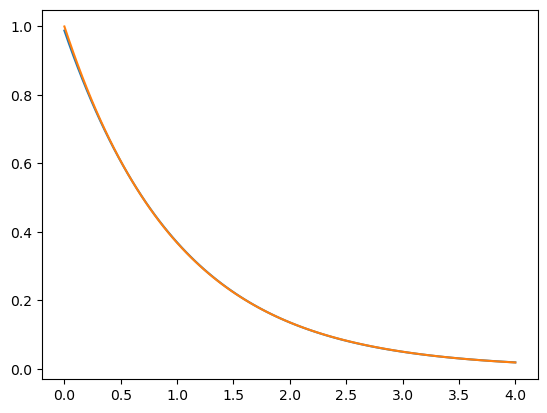

In [71]:
# small test bed for seeing how this works
# for right now calculate a weibull function and the first couple moments
# then use those moments to estimate the pdf by minnimizing the pdf (e.g. MP 2.7)
# lastly recalculate the pdf and plot a comparison
# note - this only works with the first 3 moments right now, not sure why.

# make some sample weibull data
x=np.linspace(0,4,101)
k=1
y = k*x**(k-1)*np.exp(-x**k)
dx=x[1]-x[0]
print( np.sum(y*(x[1]-x[0])) )

# calculate a couple of moments 
N=4
un = np.zeros(N)
for n in range(1,N+1):
    un[n-1] = np.sum(y*x**n*dx)

print(un)

# minnimize the potential function (MP 2.7)
state = opt.minimize(
    fun = lambda l : getGamma(l,np.array([un[0],un[1],un[2]]),x),
    x0 = np.array([1,2,3]),
    # fun = lambda l : getGamma(l,un,x),
    # x0 = np.array([1,2,3,4]),
 #   method='SLSQP'
)

# find lambda0 from MP 2.4 
print(state)
lam = state.x
Gamma = state.fun
lam0 = Gamma - np.sum(un[:3]*lam)

print(lam0,lam)

# calculate the pdf from MP 2.1 
P = getPN(lam0,lam,x)

plt.plot(x,P/np.sum(P*dx))
plt.plot(x,y)